In [1]:
import gymnasium as gym
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import matplotlib.pyplot as plt
import imageio
import os
from Helper import save_checkpoint_generic, load_checkpoint_generic

# set random seed for reproducibility
manualSeed = 999
random.seed(manualSeed)
torch.manual_seed(manualSeed)
np.random.seed(manualSeed)

print("Gym version:", gym.__version__)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


Gym version: 1.2.2
Torch version: 2.9.0+cu126
CUDA available: True


In [2]:
class ReplayBuffer:
    """Experience replay buffer for storing transitions."""
    def __init__(self, capacity):
        self.capacity = capacity
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states),
            np.array(actions),
            np.array(rewards, dtype=np.float32),
            np.array(next_states),
            np.array(dones, dtype=np.float32)
        )

    def __len__(self):
        return len(self.buffer)


In [3]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, n_hidden=128):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, n_hidden)
        self.out = nn.Linear(n_hidden, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.out(x)


In [4]:
class DQN_Agent:
    """Standard DQN agent with target network for stable learning."""
    def __init__(self, state_dim, action_dim,
                 gamma=0.99, lr=1e-3,
                 epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.995,
                 buffer_capacity=100_000, batch_size=64,
                 target_update_freq=1000,
                 n_hidden=128,
                 device="cpu"):

        if isinstance(device, torch.device):
            self.device = device
        else:
            self.device = torch.device(device)

        # Q-network and target network
        self.policy_net = QNetwork(state_dim, action_dim, n_hidden=n_hidden).to(self.device)
        self.target_net = QNetwork(state_dim, action_dim, n_hidden=n_hidden).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.memory = ReplayBuffer(buffer_capacity)

        self.gamma = gamma
        self.batch_size = batch_size
        self.action_dim = action_dim

        # epsilon-greedy params
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay

        # target network update frequency
        self.target_update_freq = target_update_freq
        self.train_step_counter = 0

    def select_action(self, state):
        """Epsilon-greedy: explore randomly or exploit best action."""
        if np.random.random() < self.epsilon:
            return np.random.randint(self.action_dim)
        state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_values = self.policy_net(state_tensor)
        return torch.argmax(q_values, dim=1).item()

    def train_step(self):
        """Train on one batch using standard DQN update."""
        if len(self.memory) < self.batch_size:
            return None

        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)

        states = torch.tensor(states, dtype=torch.float32).to(self.device)
        actions = torch.tensor(actions, dtype=torch.int64).unsqueeze(1).to(self.device)
        rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1).to(self.device)
        next_states = torch.tensor(next_states, dtype=torch.float32).to(self.device)
        dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1).to(self.device)

        # current Q values
        q_values = self.policy_net(states).gather(1, actions)

        # DQN target: max Q-value from target network
        with torch.no_grad():
            next_q_values = self.target_net(next_states).max(dim=1, keepdim=True)[0]
            target_q = rewards + (1 - dones) * self.gamma * next_q_values

        loss = nn.MSELoss()(q_values, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # decay epsilon
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

        # update target network periodically
        self.train_step_counter += 1
        if self.target_update_freq > 0 and (self.train_step_counter % self.target_update_freq == 0):
            self.target_net.load_state_dict(self.policy_net.state_dict())

        return loss.item()


In [5]:
# DQN Training
dqn_config = {
    'batch_size': 64,
    'max_steps_per_episode': 1000,
    'learning_rate': 1e-3,
    'gamma': 0.99,
    'mem_size': 10_000,
    'n_hidden': 128,
    'num_episodes': 5000,
    'output_dir': 'output_dqn',
    'checkpoint_freq': 100,
    'target_update_freq': 1000
}

# create output folders
dqn_config['checkpoint_dir'] = os.path.join(dqn_config['output_dir'], 'checkpoints')
dqn_config['plots_dir'] = os.path.join(dqn_config['output_dir'], 'plots')
dqn_config['gifs_dir'] = os.path.join(dqn_config['output_dir'], 'gifs')

os.makedirs(dqn_config['checkpoint_dir'], exist_ok=True)
os.makedirs(dqn_config['plots_dir'], exist_ok=True)
os.makedirs(dqn_config['gifs_dir'], exist_ok=True)

env = gym.make("LunarLander-v3")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

dqn_agent = DQN_Agent(
    state_dim=8,
    action_dim=4,
    gamma=dqn_config['gamma'],
    lr=dqn_config['learning_rate'],
    buffer_capacity=dqn_config['mem_size'],
    batch_size=dqn_config['batch_size'],
    n_hidden=dqn_config['n_hidden'],
    target_update_freq=dqn_config['target_update_freq'],
    device=device
)

# load checkpoint if it exists
checkpoint = load_checkpoint_generic(dqn_config['checkpoint_dir'], device=device)
start_episode = 0
dqn_reward_history = []
if checkpoint:
    if 'policy_net' in checkpoint:
        dqn_agent.policy_net.load_state_dict(checkpoint['policy_net'])
    if 'target_net' in checkpoint:
        dqn_agent.target_net.load_state_dict(checkpoint['target_net'])
    if 'optimizer' in checkpoint:
        try:
            dqn_agent.optimizer.load_state_dict(checkpoint['optimizer'])
        except Exception:
            print('Could not restore optimizer state')
    start_episode = checkpoint.get('epoch', 0)
    dqn_reward_history = checkpoint.get('reward_history', [])
    dqn_agent.epsilon = checkpoint.get('epsilon', dqn_agent.epsilon)

# training loop
num_episodes = dqn_config['num_episodes']
max_steps = dqn_config['max_steps_per_episode']
checkpoint_dir = dqn_config['checkpoint_dir']
checkpoint_freq = dqn_config['checkpoint_freq']

print(f"Starting DQN training from episode {start_episode} (device={dqn_agent.device})")

for episode in range(start_episode, num_episodes):
    state, _ = env.reset()
    total_reward = 0.0

    for t in range(max_steps):
        action = dqn_agent.select_action(state)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        dqn_agent.memory.push(state, action, reward, next_state, done)
        loss = dqn_agent.train_step()

        state = next_state
        total_reward += reward

        if done:
            break

    dqn_reward_history.append(total_reward)

    # logging
    last10 = dqn_reward_history[-10:]
    avg_last10 = float(np.mean(last10)) if last10 else 0.0
    print(f"Episode {episode + 1}/{num_episodes} | Reward: {total_reward:.2f} | Avg10: {avg_last10:.2f}")

    # save checkpoint
    if (episode + 1) % checkpoint_freq == 0 or (episode + 1) == num_episodes:
        save_checkpoint_generic(checkpoint_dir, episode + 1, {
            'policy_net': dqn_agent.policy_net.state_dict(),
            'target_net': dqn_agent.target_net.state_dict(),
            'optimizer': dqn_agent.optimizer.state_dict(),
            'epoch': episode + 1,
            'reward_history': dqn_reward_history,
            'epsilon': dqn_agent.epsilon,
            'config': dqn_config
        })

    # early stopping if solved
    if len(dqn_reward_history) >= 10:
        avg10 = np.mean(dqn_reward_history[-10:])
        if avg10 >= 250:
            print(f"Solved in episode {episode + 1} with avg10={avg10:.2f}")
            save_checkpoint_generic(checkpoint_dir, episode + 1, {
                'policy_net': dqn_agent.policy_net.state_dict(),
                'target_net': dqn_agent.target_net.state_dict(),
                'optimizer': dqn_agent.optimizer.state_dict(),
                'epoch': episode + 1,
                'reward_history': dqn_reward_history,
                'epsilon': dqn_agent.epsilon,
                'config': dqn_config
            })
            break

env.close()
print("DQN training complete.")


Using device: cuda
🚀 No checkpoint found, starting from scratch
Starting DQN training from episode 0 (device=cuda)
Episode 1/5000 | Reward: -217.72 | Avg10: -217.72
Episode 2/5000 | Reward: -48.34 | Avg10: -133.03
Episode 3/5000 | Reward: -301.99 | Avg10: -189.35
Episode 4/5000 | Reward: -251.98 | Avg10: -205.01
Episode 5/5000 | Reward: -489.37 | Avg10: -261.88
Episode 6/5000 | Reward: -260.53 | Avg10: -261.66
Episode 7/5000 | Reward: -511.90 | Avg10: -297.40
Episode 8/5000 | Reward: -312.98 | Avg10: -299.35
Episode 9/5000 | Reward: -201.82 | Avg10: -288.51
Episode 10/5000 | Reward: -66.61 | Avg10: -266.32
Episode 11/5000 | Reward: -110.34 | Avg10: -255.59
Episode 12/5000 | Reward: -319.46 | Avg10: -282.70
Episode 13/5000 | Reward: -143.20 | Avg10: -266.82
Episode 14/5000 | Reward: -414.21 | Avg10: -283.04
Episode 15/5000 | Reward: -201.54 | Avg10: -254.26
Episode 16/5000 | Reward: -507.07 | Avg10: -278.91
Episode 17/5000 | Reward: -374.30 | Avg10: -265.15
Episode 18/5000 | Reward: -24

In [6]:
class DDQNAgent:
    """Double DQN agent - uses policy_net to select actions, target_net to evaluate them."""
    def __init__(self, state_dim, action_dim,
                 gamma=0.99, lr=1e-3,
                 epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.995,
                 buffer_capacity=100_000, batch_size=64,
                 target_update_freq=1000,
                 n_hidden=128,
                 device="cpu"):

        if isinstance(device, torch.device):
            self.device = device
        else:
            self.device = torch.device(device)

        # online and target networks
        self.policy_net = QNetwork(state_dim, action_dim, n_hidden=n_hidden).to(self.device)
        self.target_net = QNetwork(state_dim, action_dim, n_hidden=n_hidden).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.memory = ReplayBuffer(buffer_capacity)

        self.gamma = gamma
        self.batch_size = batch_size
        self.action_dim = action_dim

        # epsilon-greedy params
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay

        # target network update frequency
        self.target_update_freq = target_update_freq
        self.train_step_counter = 0

    def select_action(self, state):
        """Epsilon-greedy: explore randomly or exploit best action."""
        if np.random.random() < self.epsilon:
            return np.random.randint(self.action_dim)
        state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_values = self.policy_net(state_tensor)
        return torch.argmax(q_values, dim=1).item()

    def train_step(self):
        """Train using Double DQN: select with policy_net, evaluate with target_net."""
        if len(self.memory) < self.batch_size:
            return None

        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)

        states = torch.tensor(states, dtype=torch.float32).to(self.device)
        actions = torch.tensor(actions, dtype=torch.int64).unsqueeze(1).to(self.device)
        rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1).to(self.device)
        next_states = torch.tensor(next_states, dtype=torch.float32).to(self.device)
        dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1).to(self.device)

        q_values = self.policy_net(states).gather(1, actions)

        # Double DQN: select action with policy_net, evaluate with target_net
        with torch.no_grad():
            next_actions = self.policy_net(next_states).argmax(dim=1, keepdim=True)
            next_q_values = self.target_net(next_states).gather(1, next_actions)
            target_q = rewards + (1 - dones) * self.gamma * next_q_values

        loss = nn.MSELoss()(q_values, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # decay epsilon
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

        # update target network periodically
        self.train_step_counter += 1
        if self.target_update_freq > 0 and (self.train_step_counter % self.target_update_freq == 0):
            self.target_net.load_state_dict(self.policy_net.state_dict())

        return loss.item()


In [7]:
# DDQN Training
ddqn_config = {
    'batch_size': 64,
    'max_steps_per_episode': 1000,
    'learning_rate': 1e-3,
    'gamma': 0.99,
    'mem_size': 10_000,
    'n_hidden': 128,
    'num_episodes': 5000,
    'output_dir': 'output_ddqn',
    'checkpoint_freq': 100,
    'target_update_freq': 1000
}

# create output folders
ddqn_config['checkpoint_dir'] = os.path.join(ddqn_config['output_dir'], 'checkpoints')
ddqn_config['plots_dir'] = os.path.join(ddqn_config['output_dir'], 'plots')
ddqn_config['gifs_dir'] = os.path.join(ddqn_config['output_dir'], 'gifs')

os.makedirs(ddqn_config['checkpoint_dir'], exist_ok=True)
os.makedirs(ddqn_config['plots_dir'], exist_ok=True)
os.makedirs(ddqn_config['gifs_dir'], exist_ok=True)

env = gym.make("LunarLander-v3")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

ddqn_agent = DDQNAgent(
    state_dim=8,
    action_dim=4,
    gamma=ddqn_config['gamma'],
    lr=ddqn_config['learning_rate'],
    buffer_capacity=ddqn_config['mem_size'],
    batch_size=ddqn_config['batch_size'],
    n_hidden=ddqn_config['n_hidden'],
    target_update_freq=ddqn_config['target_update_freq'],
    device=device
)

# load checkpoint if it exists
checkpoint = load_checkpoint_generic(ddqn_config['checkpoint_dir'], device=device)
start_episode = 0
ddqn_reward_history = []
if checkpoint:
    if 'policy_net' in checkpoint:
        ddqn_agent.policy_net.load_state_dict(checkpoint['policy_net'])
    if 'target_net' in checkpoint:
        ddqn_agent.target_net.load_state_dict(checkpoint['target_net'])
    if 'optimizer' in checkpoint:
        try:
            ddqn_agent.optimizer.load_state_dict(checkpoint['optimizer'])
        except Exception:
            print('Could not restore optimizer state')
    start_episode = checkpoint.get('epoch', 0)
    ddqn_reward_history = checkpoint.get('reward_history', [])
    ddqn_agent.epsilon = checkpoint.get('epsilon', ddqn_agent.epsilon)

# training loop
num_episodes = ddqn_config['num_episodes']
max_steps = ddqn_config['max_steps_per_episode']
checkpoint_dir = ddqn_config['checkpoint_dir']
checkpoint_freq = ddqn_config['checkpoint_freq']

print(f"Starting DDQN training from episode {start_episode} (device={ddqn_agent.device})")

for episode in range(start_episode, num_episodes):
    state, _ = env.reset()
    total_reward = 0.0

    for t in range(max_steps):
        action = ddqn_agent.select_action(state)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        ddqn_agent.memory.push(state, action, reward, next_state, done)
        loss = ddqn_agent.train_step()

        state = next_state
        total_reward += reward

        if done:
            break

    ddqn_reward_history.append(total_reward)

    # logging
    last10 = ddqn_reward_history[-10:]
    avg_last10 = float(np.mean(last10)) if last10 else 0.0
    print(f"Episode {episode + 1}/{num_episodes} | Reward: {total_reward:.2f} | Avg10: {avg_last10:.2f}")

    # save checkpoint
    if (episode + 1) % checkpoint_freq == 0 or (episode + 1) == num_episodes:
        save_checkpoint_generic(checkpoint_dir, episode + 1, {
            'policy_net': ddqn_agent.policy_net.state_dict(),
            'target_net': ddqn_agent.target_net.state_dict(),
            'optimizer': ddqn_agent.optimizer.state_dict(),
            'epoch': episode + 1,
            'reward_history': ddqn_reward_history,
            'epsilon': ddqn_agent.epsilon,
            'config': ddqn_config
        })

    # early stopping if solved
    if len(ddqn_reward_history) >= 10:
        avg10 = np.mean(ddqn_reward_history[-10:])
        if avg10 >= 200:
            print(f"Solved in episode {episode + 1} with avg10={avg10:.2f}")
            save_checkpoint_generic(checkpoint_dir, episode + 1, {
                'policy_net': ddqn_agent.policy_net.state_dict(),
                'target_net': ddqn_agent.target_net.state_dict(),
                'optimizer': ddqn_agent.optimizer.state_dict(),
                'epoch': episode + 1,
                'reward_history': ddqn_reward_history,
                'epsilon': ddqn_agent.epsilon,
                'config': ddqn_config
            })
            break

env.close()
print("DDQN training complete.")


Using device: cuda
🚀 No checkpoint found, starting from scratch
Starting DDQN training from episode 0 (device=cuda)
Episode 1/5000 | Reward: -189.26 | Avg10: -189.26
Episode 2/5000 | Reward: -287.95 | Avg10: -238.60
Episode 3/5000 | Reward: -137.86 | Avg10: -205.02
Episode 4/5000 | Reward: -536.97 | Avg10: -288.01
Episode 5/5000 | Reward: -370.21 | Avg10: -304.45
Episode 6/5000 | Reward: -396.92 | Avg10: -319.86
Episode 7/5000 | Reward: -312.19 | Avg10: -318.77
Episode 8/5000 | Reward: -77.49 | Avg10: -288.61
Episode 9/5000 | Reward: -246.83 | Avg10: -283.96
Episode 10/5000 | Reward: -304.53 | Avg10: -286.02
Episode 11/5000 | Reward: -102.35 | Avg10: -277.33
Episode 12/5000 | Reward: -190.51 | Avg10: -267.59
Episode 13/5000 | Reward: -241.73 | Avg10: -277.97
Episode 14/5000 | Reward: -192.49 | Avg10: -243.53
Episode 15/5000 | Reward: -262.75 | Avg10: -232.78
Episode 16/5000 | Reward: -209.90 | Avg10: -214.08
Episode 17/5000 | Reward: -361.42 | Avg10: -219.00
Episode 18/5000 | Reward: -

In [8]:
def plot_rewards(reward_history, save_path=None, show=True, title='Training Reward'):
    """Plot reward history and save to file if path provided."""
    if not reward_history:
        print('No reward history to plot')
        return None

    fig = plt.figure(figsize=(12, 5))
    plt.plot(reward_history)
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.title(title)
    plt.grid(True)

    if save_path:
        try:
            fig.savefig(save_path)
            print(f'Saved reward plot to: {save_path}')
        except Exception as e:
            print('Could not save plot:', e)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig


def create_eval_gifs(agent, out_dir='eval_gifs', env_name='LunarLander-v3',
                     num_rollouts=5, max_steps_per_rollout=500, fps=30,
                     eval_epsilon=0.01, render_mode='rgb_array'):
    """Run evaluation rollouts and save GIFs."""
    os.makedirs(out_dir, exist_ok=True)
    combined_frames = []
    created = []

    # set agent to eval mode
    agent.policy_net.eval()
    _orig_epsilon = getattr(agent, 'epsilon', None)
    agent.epsilon = min(eval_epsilon, agent.epsilon if agent.epsilon is not None else eval_epsilon)

    for r in range(num_rollouts):
        frames = []
        try:
            env_eval = gym.make(env_name, render_mode=render_mode)
        except Exception as e:
            print('Could not create renderable environment:', e)
            break

        state, _ = env_eval.reset()
        done = False
        steps = 0

        while (not done) and steps < max_steps_per_rollout:
            try:
                frame = env_eval.render()
                if frame is not None:
                    frames.append(frame)
                    combined_frames.append(frame)
            except Exception:
                pass

            action = agent.select_action(state)
            next_state, reward, terminated, truncated, info = env_eval.step(action)
            done = terminated or truncated
            state = next_state
            steps += 1

        env_eval.close()

        if not frames:
            print(f'rollout {r} produced no frames')
            continue

        gif_path = os.path.join(out_dir, f'{env_name}_rollout_{r+1}.gif')
        try:
            imageio.mimsave(gif_path, frames, fps=fps)
            created.append(gif_path)
            print(f'Saved: {gif_path}')
        except Exception as e:
            print('Could not save gif:', e)

        # add separator frames
        import numpy as _np
        black_frame = _np.zeros_like(frames[0])
        for _ in range(5):
            combined_frames.append(black_frame)

    # restore epsilon
    if _orig_epsilon is not None:
        agent.epsilon = _orig_epsilon

    combined_path = None
    if combined_frames:
        combined_path = os.path.join(out_dir, f'{env_name}_combined.gif')
        try:
            imageio.mimsave(combined_path, combined_frames, fps=fps)
            print(f'Saved combined gif: {combined_path}')
        except Exception as e:
            print('Could not save combined gif:', e)

    return created, combined_path


Saved reward plot to: output_dqn\plots\dqn_training_rewards.png


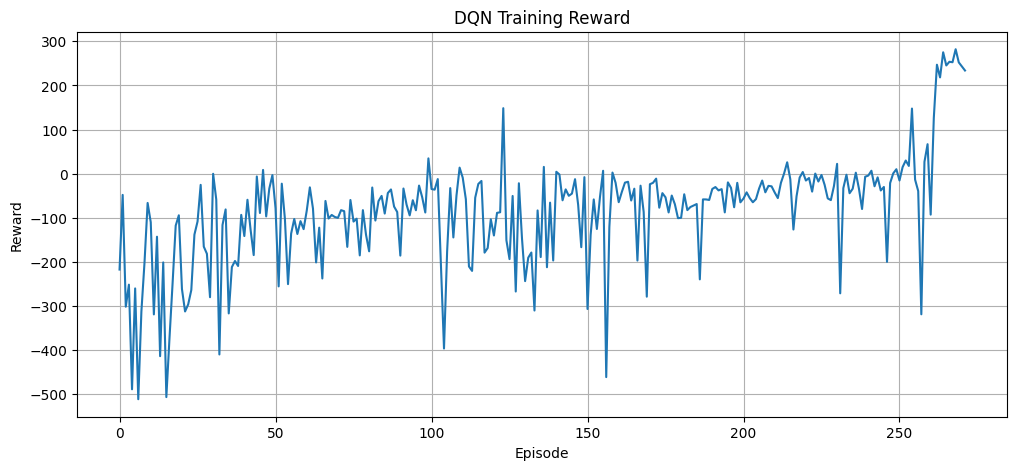

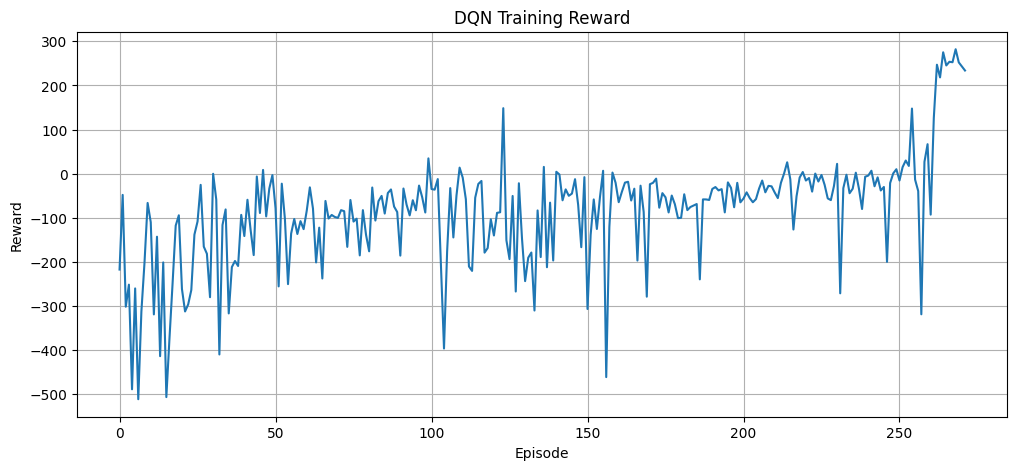

In [9]:
# Plot DQN results
plot_rewards(dqn_reward_history,
             save_path=os.path.join(dqn_config['plots_dir'], 'dqn_training_rewards.png'),
             show=True,
             title='DQN Training Reward')


In [10]:
# Create evaluation GIFs for DQN agent
create_eval_gifs(dqn_agent,
                 out_dir=dqn_config['gifs_dir'],
                 env_name='LunarLander-v3',
                 num_rollouts=5,
                 max_steps_per_rollout=500)


Saved: output_dqn\gifs\LunarLander-v3_rollout_1.gif
Saved: output_dqn\gifs\LunarLander-v3_rollout_2.gif
Saved: output_dqn\gifs\LunarLander-v3_rollout_3.gif
Saved: output_dqn\gifs\LunarLander-v3_rollout_4.gif
Saved: output_dqn\gifs\LunarLander-v3_rollout_5.gif
Saved combined gif: output_dqn\gifs\LunarLander-v3_combined.gif


(['output_dqn\\gifs\\LunarLander-v3_rollout_1.gif',
  'output_dqn\\gifs\\LunarLander-v3_rollout_2.gif',
  'output_dqn\\gifs\\LunarLander-v3_rollout_3.gif',
  'output_dqn\\gifs\\LunarLander-v3_rollout_4.gif',
  'output_dqn\\gifs\\LunarLander-v3_rollout_5.gif'],
 'output_dqn\\gifs\\LunarLander-v3_combined.gif')

Saved reward plot to: output_ddqn\plots\ddqn_training_rewards.png


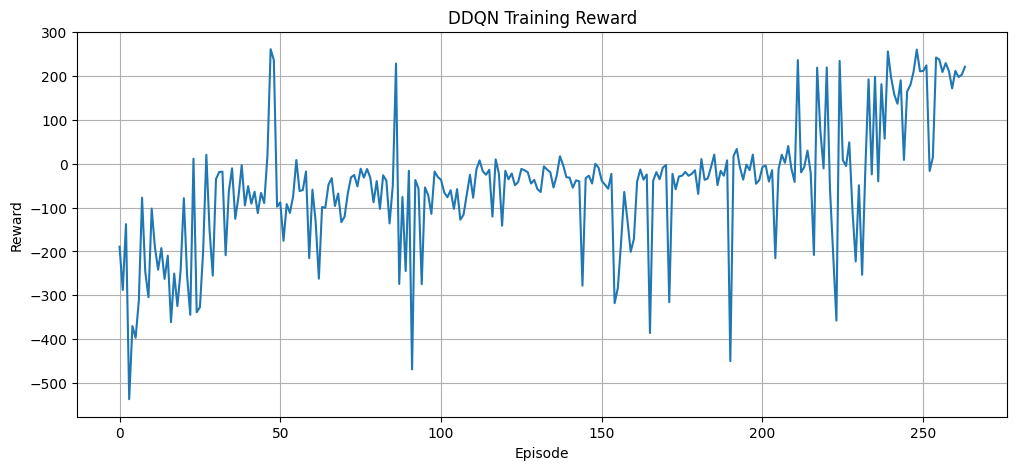

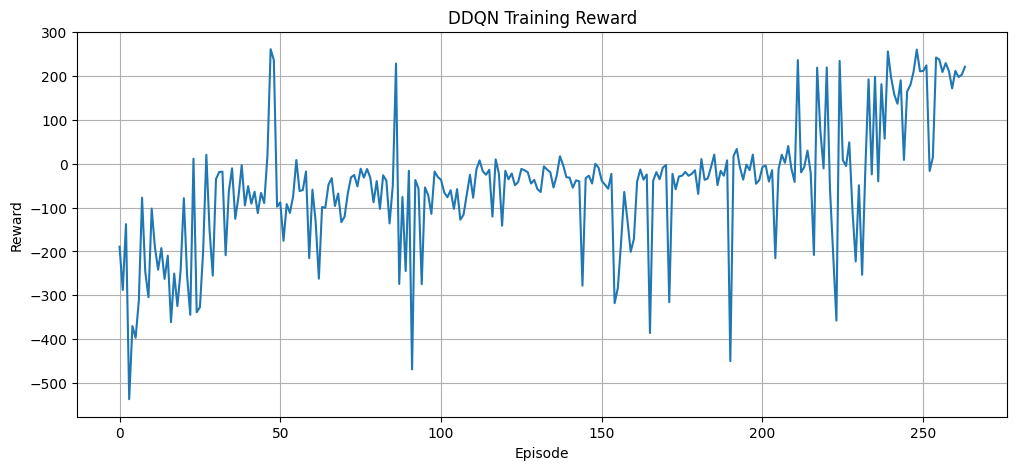

In [11]:
# Plot DDQN results
plot_rewards(ddqn_reward_history,
             save_path=os.path.join(ddqn_config['plots_dir'], 'ddqn_training_rewards.png'),
             show=True,
             title='DDQN Training Reward')


In [12]:
# Create evaluation GIFs for DDQN agent
create_eval_gifs(ddqn_agent,
                 out_dir=ddqn_config['gifs_dir'],
                 env_name='LunarLander-v3',
                 num_rollouts=5,
                 max_steps_per_rollout=500)


Saved: output_ddqn\gifs\LunarLander-v3_rollout_1.gif
Saved: output_ddqn\gifs\LunarLander-v3_rollout_2.gif
Saved: output_ddqn\gifs\LunarLander-v3_rollout_3.gif
Saved: output_ddqn\gifs\LunarLander-v3_rollout_4.gif
Saved: output_ddqn\gifs\LunarLander-v3_rollout_5.gif
Saved combined gif: output_ddqn\gifs\LunarLander-v3_combined.gif


(['output_ddqn\\gifs\\LunarLander-v3_rollout_1.gif',
  'output_ddqn\\gifs\\LunarLander-v3_rollout_2.gif',
  'output_ddqn\\gifs\\LunarLander-v3_rollout_3.gif',
  'output_ddqn\\gifs\\LunarLander-v3_rollout_4.gif',
  'output_ddqn\\gifs\\LunarLander-v3_rollout_5.gif'],
 'output_ddqn\\gifs\\LunarLander-v3_combined.gif')